In [3]:
import requests as requests

import pandas as pd 
import json
import io
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import random


In [4]:
import requests as requests
r = requests.get("https://re.jrc.ec.europa.eu/api/seriescalc?lat=45&lon=8&outputformat=json")
df = r.json()


In [5]:
data=df

In [6]:
data

{'inputs': {'location': {'latitude': 45.0,
   'longitude': 8.0,
   'elevation': 250.0},
  'meteo_data': {'radiation_db': 'PVGIS-SARAH',
   'meteo_db': 'ERA-Interim',
   'year_min': 2005,
   'year_max': 2016,
   'use_horizon': True,
   'horizon_db': None,
   'horizon_data': 'DEM-calculated'},
  'mounting_system': {'fixed': {'slope': {'value': 0, 'optimal': False},
    'azimuth': {'value': 0, 'optimal': False},
    'type': 'free-standing'}},
  'pv_module': {'technology': None, 'peak_power': None, 'system_loss': None}},
 'outputs': {'hourly': [{'time': '20050101:0010',
    'G(i)': 0.0,
    'H_sun': 0.0,
    'T2m': -2.15,
    'WS10m': 2.54,
    'Int': 0.0},
   {'time': '20050101:0110',
    'G(i)': 0.0,
    'H_sun': 0.0,
    'T2m': -2.32,
    'WS10m': 2.54,
    'Int': 0.0},
   {'time': '20050101:0210',
    'G(i)': 0.0,
    'H_sun': 0.0,
    'T2m': -2.49,
    'WS10m': 2.54,
    'Int': 0.0},
   {'time': '20050101:0310',
    'G(i)': 0.0,
    'H_sun': 0.0,
    'T2m': -2.66,
    'WS10m': 2.54,
 

In [7]:
j=data["outputs"]["hourly"]


In [8]:
j

[{'time': '20050101:0010',
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': -2.15,
  'WS10m': 2.54,
  'Int': 0.0},
 {'time': '20050101:0110',
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': -2.32,
  'WS10m': 2.54,
  'Int': 0.0},
 {'time': '20050101:0210',
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': -2.49,
  'WS10m': 2.54,
  'Int': 0.0},
 {'time': '20050101:0310',
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': -2.66,
  'WS10m': 2.54,
  'Int': 0.0},
 {'time': '20050101:0410',
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': -2.44,
  'WS10m': 2.52,
  'Int': 0.0},
 {'time': '20050101:0510',
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': -2.22,
  'WS10m': 2.51,
  'Int': 0.0},
 {'time': '20050101:0610',
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': -1.99,
  'WS10m': 2.5,
  'Int': 0.0},
 {'time': '20050101:0710',
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': -0.47,
  'WS10m': 2.51,
  'Int': 0.0},
 {'time': '20050101:0810',
  'G(i)': 67.0,
  'H_sun': 8.06,
  'T2m': 1.05,
  'WS10m': 2.52,
  'Int': 0.0},
 {'time': '20050101:0910',
  'G(i)': 206.01,
 

In [9]:

jf= json.dumps(j, indent=2)
df=pd.read_json(jf, orient='records') 
# df

In [14]:
df

,time,G(i),H_sun,T2m,WS10m,Int
0,20050101:0010,0.0,0.0,-2.15,2.54,0
1,20050101:0110,0.0,0.0,-2.32,2.54,0
2,20050101:0210,0.0,0.0,-2.49,2.54,0
3,20050101:0310,0.0,0.0,-2.66,2.54,0
4,20050101:0410,0.0,0.0,-2.44,2.52,0
...,...,...,...,...,...,...
105187,20161231:1910,0.0,0.0,1.64,1.02,0
105188,20161231:2010,0.0,0.0,0.46,1.05,0
105189,20161231:2110,0.0,0.0,-0.72,1.09,0
105190,20161231:2210,0.0,0.0,-0.72,1.09,0


In [10]:
print(df.shape)

(105192, 6)


In [11]:
dfh=df.head(100)

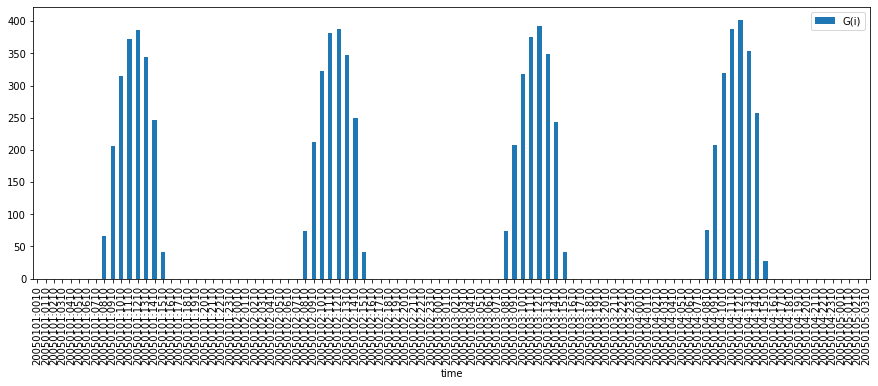

In [13]:
fig = Figure()
fig=dfh.plot(kind='bar',x='time',y=['G(i)'],figsize=(15,5));



In [50]:
    output = io.BytesIO()
    FigureCanvas(fig).print_png(output)
    aa=output.getvalue()

In [68]:
import matplotlib.pyplot as plt
import base64
from io import BytesIO

fig = plt.figure()
#plot sth

tmpfile = BytesIO()
fig.savefig(tmpfile, format='png')
encoded = base64.b64encode(tmpfile.getvalue()).decode('utf-8')


<Figure size 432x288 with 0 Axes>

In [69]:
encoded


'iVBORw0KGgoAAAANSUhEUgAAAbAAAAEgCAYAAADVKCZpAAAABHNCSVQICAgIfAhkiAAAAAlwSFlzAAALEgAACxIB0t1+/AAAADh0RVh0U29mdHdhcmUAbWF0cGxvdGxpYiB2ZXJzaW9uMy4yLjEsIGh0dHA6Ly9tYXRwbG90bGliLm9yZy+j8jraAAAEV0lEQVR4nO3VQQ0AIBDAMMC/58MDH7KkVbDf9szMAoCY8zsAAF4YGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQZGABJBgZAkoEBkGRgACQ

In [65]:
from IPython.display import HTML

HTML('''
 <img style='display:block; width:100px;height:100px;' id='base64image'                 
       src='data:image/jpeg;base64, {{encoded}}' />''')

<img src='data:image/png;base64,{{encoded}}'>

fasfasfdasf 
![Hello World](data:image/png;base64,{{encoded}})



Markdown | Less | Pretty
--- | --- | ---
*Still* | `renders` | **nicely**
1 | 2 | 3

<dl>
  <dt>Definition list</dt>
  <dd>Is something people use sometimes.</dd>

  <dt>Markdown in HTML</dt>
  <dd>Does *not* work **very** well. Use HTML <em>tags</em>.</dd>
</dl>


<a href="http://www.youtube.com/watch?feature=player_embedded&v=YOUTUBE_VIDEO_ID_HERE
" target="_blank"><img src="http://img.youtube.com/vi/YOUTUBE_VIDEO_ID_HERE/0.jpg" 
alt="IMAGE ALT TEXT HERE" width="240" height="180" border="10" /></a>

Hello World

In [ ]:
k=j["hourly"]
# print(k)
kf= json.dumps(k, indent=2)
df=pd.read_json(kf, orient='records') 
df[8:129]

In [ ]:
df.dtypes

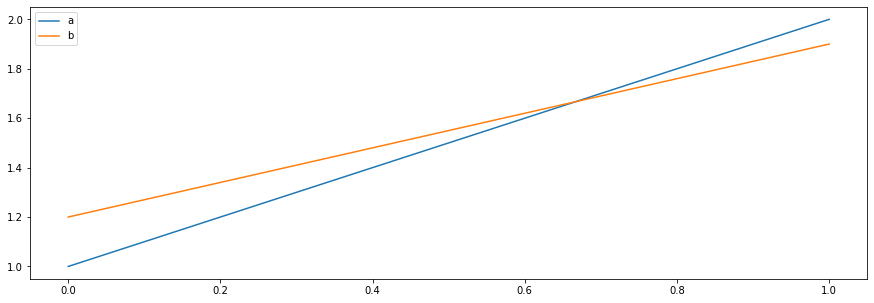

In [12]:
df = pd.DataFrame({"a":[1,2],"b":[1.2,1.9]})
df.plot(figsize=(15,5));

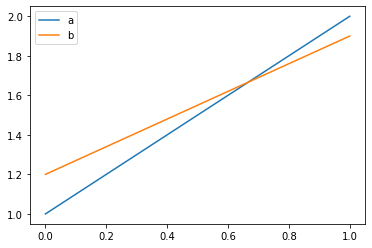

In [17]:
df.plot();

In [22]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="."></form>''')